# Plots for figure.

## Prepare notebook.

### Import Libraries.

In [45]:
import os

import numpy as np
import pandas as pd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import scanpy as sc
import seaborn as sns
from tqdm import tqdm
import scvi


### Define constants and paths.

In [29]:
h5ad_path = "/lustre/groups/ml01/workspace/alessandro.palma/celldreamer/datasets/processed_full_genome/neurips/neurips.h5ad"
dataset_dir = "/home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/Neurips"
plots_dir = os.path.join(dataset_dir, "plots_data")
results_dir = os.path.join(dataset_dir, "cfm_runs")

dims = [2, 5, 10, 50, 100, 200]
scvi_models_dir = "/home/icb/lorenzo.consoli/repos/scFM_density_estimation/dumps/Neurips/scvi_runs"
dim2scvipath = {
    dim: os.path.join(scvi_models_dir, run) for dim in dims for run in os.listdir(scvi_models_dir) if run.startswith(f"dim-{dim}")
}

dim2yticks = {
    50: [0.0, 2.5, 5.0]
}
dim2xticks = {
    50: [0.0, 2.0, 4.0]
}
dim2xlim = {
    50: [0.0, 4.0]
}
dim2ylim = {
    50: [0.0, 5.0]
}

colors_dict = {
    "dark-red": "#780000",
    "light-red": "#C1121F",
    "light-yellow": "#FDF0D5",
    "dark-blue": "#003049",
    "light-blue": "#669BBC",
}

palette_12 = [
    "#780000",  # dark-red
    "#C1121F",  # light-red
    "#E63946",  # pink
    "#003049",  # dark-blue
    "#669BBC",  # light-blue
    "#A8DADC",  # sky-blue
    "#00798C",  # teal
    "#FDF0D5",  # light-yellow
    "#FFD166",  # gold
    "#EAB543",  # mustard
    "#343A40",  # dark-gray
    "#6C757D",  # neutral-gray
]


### Utility functions.

In [32]:
def plot_llr_densities(
    cllr,
    ullr,
    title="",
    xlabel="",
    ylabel="Density",
    bins="auto",
    suptitlesize=30,
    xlabelsize=25,
    ylabelsize=25,
    xticks=None,
    yticks=None,
    xticks_size=20,
    yticks_size=20,
    xlim=None,
    ylim=None,
):
    # defined ax and figure
    fig, ax = plt.subplots(figsize=(12.5, 5))
    fig.suptitle(title, size=suptitlesize)
    # corrected
    sns.histplot(cllr, bins=bins, alpha=0.4, color=colors_dict["light-blue"], label="corrected", stat="density", ax=ax)
    sns.kdeplot(cllr, color=colors_dict["dark-blue"], ax=ax)
    # uncorrected
    sns.histplot(ullr, bins=bins, alpha=0.4, color=colors_dict["light-red"], label="uncorrected", stat="density", ax=ax)
    sns.kdeplot(ullr, color=colors_dict["dark-red"], ax=ax)
    ax.grid(False)

    # xticks
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.tick_params(axis="x", labelsize=xticks_size)
    if yticks is not None:
        ax.set_yticks(yticks)
        ax.tick_params(axis="y", labelsize=yticks_size)

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_xlabel(xlabel, size=xlabelsize)
    ax.set_ylabel(ylabel, size=ylabelsize)
    fig.tight_layout()

    handles, labels = ax.get_legend_handles_labels()
    return fig, handles, labels

def plot_llr_boxplot(
    cllr,
    ullr,
    title="",
    xlabel="LLR",
    ylabel="",
    suptitlesize=30,
    xlabelsize=25,
    ylabelsize=25,
    xticks=None,
    yticks=None,
    xticks_size=20,
    yticks_size=20,
    xlim=None,
    ylim=None,
    horizontal=True,   # NEW OPTION
    show_outliers=False,
    linewidth=7,
):
    # Prepare data
    data = pd.DataFrame({
        "Corrected": cllr,
        "Uncorrected": ullr
    })
    data_melted = data.melt(var_name="Condition", value_name="LLR")

    fig, ax = plt.subplots(figsize=(12.5, 5))
    fig.suptitle(title, size=suptitlesize)

    if horizontal:
        sns.boxplot(
            y="Condition",
            x="LLR",
            data=data_melted,
            palette={
                "Corrected": colors_dict["light-blue"],
                "Uncorrected": colors_dict["dark-red"]
            },
            ax=ax,
            showfliers=show_outliers,
            linewidth=linewidth,
        )
        if xlim is not None:
            ax.set_xlim(xlim)
        if ylim is not None:
            ax.set_ylim(ylim)
        ax.set_xlabel(xlabel, size=xlabelsize)
        ax.set_ylabel(ylabel, size=ylabelsize)

    else:
        sns.boxplot(
            x="Condition",
            y="LLR",
            data=data_melted,
            palette={
                "Corrected": colors_dict["light-blue"],
                "Uncorrected": colors_dict["dark-red"]
            },
            ax=ax,
            showfliers=show_outliers,
            linewidth=linewidth,
        )
        if ylim is not None:
            ax.set_ylim(ylim)
        if xlim is not None:
            ax.set_xlim(xlim)
        ax.set_xlabel(ylabel, size=ylabelsize)
        ax.set_ylabel(xlabel, size=xlabelsize)

    # Ticks
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.tick_params(axis="x", labelsize=xticks_size)

    if yticks is not None:
        ax.set_yticks(yticks)
    ax.tick_params(axis="y", labelsize=yticks_size)

    ax.grid(False)
    fig.tight_layout()

    handles, labels = ax.get_legend_handles_labels()
    return fig, handles, labels


def assign_palette_12(adata, obs_key, palette):
    adata.obs[obs_key] = adata.obs[obs_key].astype("category")
    n = adata.obs[obs_key].cat.categories.size

    if n > len(palette):
        raise ValueError(f"{obs_key} has {n} categories, but palette has only {len(palette)} colors")

    adata.uns[f"{obs_key}_colors"] = palette[:n]


def assign_cycled_palette(adata, obs_key, palette):
    adata.obs[obs_key] = adata.obs[obs_key].astype("category")
    cats = adata.obs[obs_key].cat.categories

    colors = [palette[i % len(palette)] for i in range(len(cats))]
    adata.uns[f"{obs_key}_colors"] = colors


## Read data and results.

### Read adata.

In [ ]:
adata = sc.read_h5ad(h5ad_path)
adata = adata[:, adata.var["highly_variable"]]
assign_palette_12(adata, "batch", palette_12)
assign_cycled_palette(adata, "cell_type", palette_12)
adata

/tmp/ipykernel_2391110/2619548248.py:134: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[obs_key] = adata.obs[obs_key].astype("category")
/home/icb/lorenzo.consoli/miniconda3/envs/sc_flow_density/lib/python3.10/site-packages/anndata/_core/anndata.py:1758: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 90261 × 2014
    obs: 'GEX_n_genes_by_counts', 'GEX_pct_counts_mt', 'GEX_size_factors', 'GEX_phase', 'ADT_n_antibodies_by_counts', 'ADT_total_counts', 'ADT_iso_count', 'cell_type', 'batch', 'ADT_pseudotime_order', 'GEX_pseudotime_order', 'Samplename', 'Site', 'DonorNumber', 'Modality', 'VendorLot', 'DonorID', 'DonorAge', 'DonorBMI', 'DonorBloodType', 'DonorRace', 'Ethnicity', 'DonorGender', 'QCMeds', 'DonorSmoker', 'is_train'
    var: 'feature_types', 'gene_id', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'cell_type_colors', 'dataset_id', 'genome', 'hvg', 'log1p', 'neighbors', 'organism', 'pca', 'umap', 'batch_colors'
    obsm: 'ADT_X_pca', 'ADT_X_umap', 'ADT_isotype_controls', 'GEX_X_pca', 'GEX_X_umap', 'X_pca', 'X_umap'
    varm: 'PCs'
    layers: 'X_counts'
    obsp: 'connectivities', 'distances'

### Plot legend.

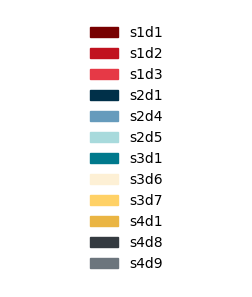

In [48]:
# Get categories and colors
cats = adata.obs["batch"].cat.categories
colors = adata.uns["batch_colors"]

# Create legend handles
handles = [mpatches.Patch(color=c, label=cat) for c, cat in zip(colors, cats)]

# Make a figure with just the legend
fig_legend = plt.figure(figsize=(3, len(handles)*0.3))
ax = fig_legend.add_subplot(111)
ax.axis("off")
ax.legend(handles=handles, loc="center", frameon=False)

fig_legend.savefig(os.path.join(plots_dir, "batch_leged.svg"), dpi=500)


### Read results for each dimension and combination.

In [5]:
results_dict = {}
runs = os.listdir(results_dir)
for idx, run_id in enumerate(runs):
    print(f"Loading run {run_id} {idx}/{len(runs)}")
    run_res_dict = {}
    run_dir = os.path.join(results_dir, run_id)
    run_res_dir = os.path.join(run_dir, "results")
    for res in tqdm(os.listdir(run_res_dir)):
        res_paths = os.path.join(run_res_dir, res)
        res_array_dic = np.load(res_paths)
        run_res_dict[res] = res_array_dic
    results_dict[run_id] = run_res_dict

Loading run 2026-01-24_00-45-25_89bb3ce8 0/6


100%|██████████| 431/431 [00:07<00:00, 54.46it/s]


Loading run 2026-01-24_00-45-25_da45835b 1/6


100%|██████████| 431/431 [00:07<00:00, 56.81it/s]


Loading run 2026-01-24_00-45-25_ecef9454 2/6


...

100%|██████████| 431/431 [00:26<00:00, 16.11it/s]


Loading run 2026-01-24_00-45-25_6176d031 4/6


100%|██████████| 431/431 [00:15<00:00, 27.34it/s]


Loading run 2026-01-24_00-45-25_21ab6c6f 5/6


100%|██████████| 431/431 [00:06<00:00, 62.03it/s]


### Concatenate results across all combinations for each dimension.

In [6]:
concat_res_dict = {}
for idx, (run, run_dict) in enumerate(results_dict.items()):
    print(f"Loading run {run} {idx}/{len(results_dict)}")
    noise_corrected = []
    llr_corrected = []
    noise_uncorrected = []
    llr_uncorrected = []
    for group_id, group_dict in tqdm(run_dict.items()):
        noise_corrected.append(group_dict["noise_corrected"])
        llr_corrected.append(group_dict["llr_corrected"])
        noise_uncorrected.append(group_dict["noise_uncorrected"])
        llr_uncorrected.append(group_dict["llr_uncorrected"])
    print(f"Concatenating results...")
    noise_corrected = np.concatenate(noise_corrected, axis=0)    
    llr_corrected = np.concatenate(llr_corrected, axis=0)    
    noise_uncorrected = np.concatenate(noise_uncorrected, axis=0)    
    llr_uncorrected = np.concatenate(llr_uncorrected, axis=0)  
    print(f"{noise_corrected.shape=}")
    print(f"{llr_corrected.shape=}")
    print(f"{noise_uncorrected.shape=}")
    print(f"{llr_uncorrected.shape=}")
    dim = noise_corrected.shape[-1]
    concat_res_dict[(run, dim)] = {
        "noise_corrected": noise_corrected,
        "llr_corrected": llr_corrected,
        "noise_uncorrected": noise_uncorrected,
        "llr_uncorrected": llr_uncorrected,
    }


Loading run 2026-01-24_00-45-25_89bb3ce8 0/6


100%|██████████| 431/431 [00:00<00:00, 1800.04it/s]


Concatenating results...
noise_corrected.shape=(90261, 10)
llr_corrected.shape=(90261,)
noise_uncorrected.shape=(90261, 10)
llr_uncorrected.shape=(90261,)
Loading run 2026-01-24_00-45-25_da45835b 1/6


100%|██████████| 431/431 [00:00<00:00, 1910.58it/s]


Concatenating results...
noise_corrected.shape=(90261, 5)
llr_corrected.shape=(90261,)
noise_uncorrected.shape=(90261, 5)
llr_uncorrected.shape=(90261,)
Loading run 2026-01-24_00-45-25_ecef9454 2/6


...

Concatenating results...
noise_corrected.shape=(90261, 2)
llr_corrected.shape=(90261,)
noise_uncorrected.shape=(90261, 2)
llr_uncorrected.shape=(90261,)
Loading run 2026-01-24_00-45-25_6176d031 4/6


100%|██████████| 431/431 [00:00<00:00, 1284.46it/s]


Concatenating results...
noise_corrected.shape=(90261, 100)
llr_corrected.shape=(90261,)
noise_uncorrected.shape=(90261, 100)
llr_uncorrected.shape=(90261,)
Loading run 2026-01-24_00-45-25_21ab6c6f 5/6


100%|██████████| 431/431 [00:00<00:00, 1569.77it/s]

Concatenating results...
noise_corrected.shape=(90261, 50)
llr_corrected.shape=(90261,)
noise_uncorrected.shape=(90261, 50)
llr_uncorrected.shape=(90261,)


## Plot results of log density ratio computation.

### Plot histogram of mean absolute log ratio.

In [7]:
dim2fig_abs = {}

for (run, dim), arrays_dict in tqdm(concat_res_dict.items()):
    xticks = dim2xticks.get(dim, None)
    yticks = dim2yticks.get(dim, None)
    xlim = dim2xlim.get(dim, None)
    ylim = dim2ylim.get(dim, None)

    run_dir = os.path.join(results_dir, run)
    run_plots_dir = os.path.join(run_dir, "plots_agg")
    os.makedirs(run_plots_dir, exist_ok=True)

    llr_corrected = np.abs(arrays_dict["llr_corrected"])
    llr_uncorrected = np.abs(arrays_dict["llr_uncorrected"])
    fig, handles, labels = plot_llr_densities(
        llr_corrected,
        llr_uncorrected,
        f"Dimension {dim}",
        "Mean Absolute Log Ratio",
        xticks=xticks,
        yticks=yticks,
        xlim=xlim,
        ylim=ylim,
    )
    dim2fig_abs[(run, dim)] = fig

    fig_legend = plt.figure(figsize=(2, 2))
    ax = fig_legend.add_subplot(111)  # Add a dummy axes
    ax.axis("off")

    fig_legend.legend(
        handles,
        labels,
        loc="center",
        fontsize=50,
        ncol=30,
        frameon=False
    )
    fig_legend.tight_layout()
    legend_path = os.path.join(run_plots_dir, "legend.svg")
    fig_legend.savefig(legend_path, dpi=300, bbox_inches="tight")
    plt.close(fig_legend)

    image_path = os.path.join(run_plots_dir, "llr_abs.svg")
    fig.savefig(image_path, dpi=500)
    plt.close(fig)


100%|██████████| 6/6 [00:10<00:00,  1.67s/it]


### Boxplot of mean absolute log density ratio.

In [23]:
box_dim2fig_abs = {}

for (run, dim), arrays_dict in tqdm(concat_res_dict.items()):
    xticks = dim2xticks.get(dim, None)
    yticks = dim2yticks.get(dim, None)
    xlim = dim2xlim.get(dim, None)
    ylim = dim2ylim.get(dim, None)

    run_dir = os.path.join(results_dir, run)
    run_plots_dir = os.path.join(run_dir, "plots_agg")
    os.makedirs(run_plots_dir, exist_ok=True)

    llr_corrected = np.abs(arrays_dict["llr_corrected"])
    llr_uncorrected = np.abs(arrays_dict["llr_uncorrected"])
    fig, handles, labels = plot_llr_boxplot(
        llr_corrected,
        llr_uncorrected,
        f"Dimension {dim}",
        "Mean Absolute Log Ratio",
        # xticks=xticks,
        # yticks=yticks,
        # xlim=xlim,
        # ylim=ylim,
        horizontal=True,
        show_outliers=False,
        linewidth=10,
        xticks_size=30,
        yticks_size=30,
        xlabelsize=30,
        ylabelsize=40,
    )
    box_dim2fig_abs[(run, dim)] = fig

    # break
    image_path = os.path.join(run_plots_dir, "no_outliers_horizontal_boxplot_llr_abs.svg")
    fig.savefig(image_path, dpi=500)
    plt.close(fig)


  0%|          | 0/6 [00:00<?, ?it/s]/tmp/ipykernel_2391110/1678959026.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
 17%|█▋        | 1/6 [00:00<00:02,  2.22it/s]/tmp/ipykernel_2391110/1678959026.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
 33%|███▎      | 2/6 [00:00<00:01,  2.24it/s]/tmp/ipykernel_2391110/1678959026.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
 50%|█████     | 3/6 [00:01<00:01,  2.20it/s]/tmp/ipykernel_2391110/1678959026.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecat

## Plot states.

### Uncorrected cell states.

In [43]:
compute_stuff = False
s = 15
uncorr_dim2umap_batch = {}
uncorr_dim2umap_cell_type = {}
for d in tqdm(dims):
    batch_dim_file = os.path.join(plots_dir, f"umap_{d}_hvgs_only_batch_size{s}.png")
    cell_type_dim_file = os.path.join(plots_dir, f"umap_{d}_hvgs_only_cell_type_size{s}.png")
    if compute_stuff:
        sc.pp.pca(adata, n_comps=d, key_added=f"X_pca_{d}")
        sc.pp.neighbors(adata, use_rep=f"X_pca_{d}", key_added=f"neighbors_pca_{d}")
        sc.tl.umap(adata, neighbors_key=f"neighbors_pca_{d}", key_added=f"umap_pca_{d}",)
    fig_batch = sc.pl.embedding(adata, f"umap_pca_{d}", s=s, color="batch", frameon=False, legend_loc=None, return_fig=True)
    fig_cell_type = sc.pl.embedding(adata, f"umap_pca_{d}", s=s, color="cell_type", frameon=False, legend_loc=None, return_fig=True)
    fig_batch.savefig(batch_dim_file, dpi=500)
    fig_cell_type.savefig(cell_type_dim_file, dpi=500)
    uncorr_dim2umap_batch[d] = fig_batch
    uncorr_dim2umap_cell_type[d] = fig_cell_type
    plt.close(fig_cell_type)
    plt.close(fig_batch)

100%|██████████| 6/6 [00:11<00:00,  1.90s/it]


### Corrected cell states.

In [44]:
compute_stuff = False
s = 15
corr_dim2umap_batch = {}
corr_dim2umap_cell_type = {}
adata = adata[:, adata.var["highly_variable"]]
for d in tqdm(dims):
    if compute_stuff:
        scvi_model_dir = dim2scvipath[d]
        scvi_model = scvi.model.SCVI.load(scvi_model_dir, adata=adata.copy())
        adata.obsm[f"X_scvi_{d}"] = scvi_model.get_latent_representation()

        sc.pp.neighbors(adata, use_rep=f"X_scvi_{d}", key_added=f"neighbors_scvi_{d}")
        sc.tl.umap(adata, neighbors_key=f"neighbors_scvi_{d}", key_added=f"umap_scvi_{d}", min_dist=0.3)

    batch_dim_file = os.path.join(plots_dir, f"scvi_umap_{d}_hvgs_only_batch_size{s}.png")
    cell_type_dim_file = os.path.join(plots_dir, f"scvi_umap_{d}_hvgs_only_cell_type_size{s}.png")

    fig_batch = sc.pl.embedding(adata, f"umap_scvi_{d}", color="batch", s=s, frameon=False, legend_loc=None, return_fig=True)
    fig_cell_type = sc.pl.embedding(adata, f"umap_scvi_{d}", color="cell_type", s=s, frameon=False, legend_loc=None, return_fig=True)

    fig_batch.savefig(batch_dim_file, dpi=500)
    fig_cell_type.savefig(cell_type_dim_file, dpi=500)
    corr_dim2umap_batch[d] = fig_batch
    corr_dim2umap_cell_type[d] = fig_cell_type
    plt.close(fig_cell_type)
    plt.close(fig_batch)

  0%|          | 0/6 [00:00<?, ?it/s]

100%|██████████| 6/6 [00:11<00:00,  1.87s/it]
